 **Analysing model performance**
- Summary of performance metrics (sharpe, sortino, calmar ratio, mdd) comparing with baselines models

- portfolio returns over time (best performing vs benchmarks)
-evolution of portfolio weights over time



In [1]:
import os
import numpy as np
import pandas as pd

filepath = os.listdir('Results')
print(filepath)

['arima_7d_rebalance_test_summary.csv', 'arima_selected_orders.csv', 'ARIMA_test_7d_rebalance_actual_matrix.npy', 'ARIMA_test_7d_rebalance_forecast_matrix.npy', 'best_correlation_cholesky_LSTM.keras', 'dcc_garch_daily_covariance_matrices.npy', 'dcc_garch_daily_covariance_matrices_test.npy', 'Features and BO new return.npy', 'lstm_cov_matrices.npy', 'XGBoost Base Forecast new return.npy', 'XGBoost Features Forecast new return.npy']


**Performance metrics Table**

In [2]:
# Load performance metrics

loaded = np.load(
    os.path.join('15 CMVO results/','all_portfolio_metrics.npy'),
    allow_pickle=True
).item()

#construct summary table

print(loaded.items())

rows = []
for model_name, record in loaded.items():
    rows.append({'portfolio': model_name, **record})

summary_df = pd.DataFrame(rows).set_index(['portfolio'])
summary_df = summary_df.sort_values(by='final_value', ascending=False)
print(summary_df.to_string())


dict_items([('xgb_base_lstm', {'final_value': np.float64(0.9256209008899956), 'total_return': np.float64(-0.0743790991100044), 'mdd': np.float64(-0.4404359582326563), 'sharpe': np.float64(0.003650432876709128), 'sortino': np.float64(0.005047961224076512), 'calmar': np.float64(-0.16887608225374348)}), ('xgb_features_lstm', {'final_value': np.float64(1.0369083889436497), 'total_return': np.float64(0.03690838894364967), 'mdd': np.float64(-0.3969787063236244), 'sharpe': np.float64(0.018719016443706403), 'sortino': np.float64(0.027250612661174546), 'calmar': np.float64(0.09297322086983997)}), ('xgb_bo_lstm', {'final_value': np.float64(1.2844378514195642), 'total_return': np.float64(0.28443785141956424), 'mdd': np.float64(-0.4065188173773829), 'sharpe': np.float64(0.04498436979181002), 'sortino': np.float64(0.06722426302269312), 'calmar': np.float64(0.6996917221559084)}), ('xgb_base_dcc', {'final_value': np.float64(0.9388494386304334), 'total_return': np.float64(-0.06115056136956665), 'mdd':

In [3]:
# #LOAD CSV OUTPUTs

# model_names = [ 'xgb_base_lstm',
#     'xgb_features_lstm',
#     'xgb_bo_lstm',
#     'xgb_base_dcc',
#     'xgb_features_dcc',
#     'xgb_bo_dcc',
#     'arima_lstm',
#     'arima_dcc',
#     'benchmark_1n',
#     'benchmark_mv']

# for model_name in model_names:
#     vars()[model_name] = pd.read_csv(
#         os.path.join('Results/', f'{model_name}.csv'),
#         index_col=0
#     )

#     print(f"Loaded {model_name}:")



**Plot portfolio value over time for all 8 portfolios**

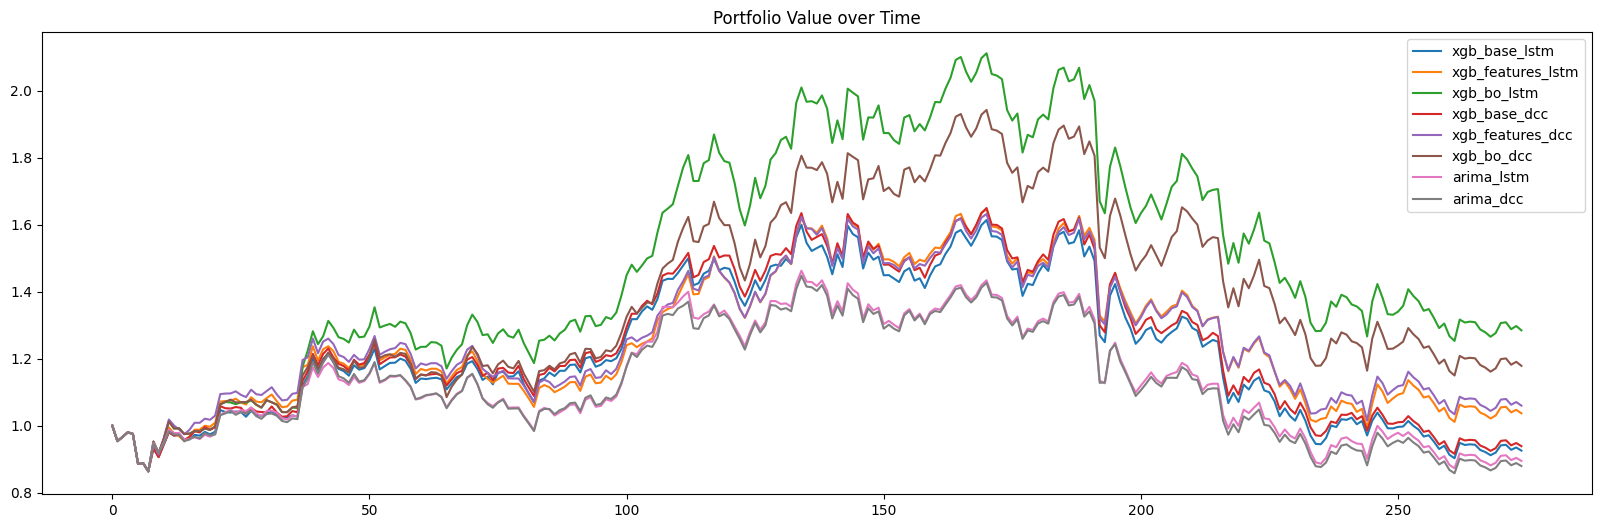

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 6))


for model_name in loaded.keys():
    # if model_name == 'Statistical MV':
    #     model_name = 'benchmark_mv'
    # if model_name == '1/N Equal Weight':
    #     model_name = 'benchmark_1n'
    csv_path = os.path.join('15 CMVO results/', f'{model_name}.csv')

    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        # Plotting the 'portfolio_value' column from the CSV
        plt.plot(df['portfolio_values'], label=model_name)

# plt.fill_between(t_values, 0, portfolio_values.max(),
#                  where=(predicted_returns> > 0.015),
#                  facecolor='green', alpha=0.2, label='High Growth Forecast')


plt.title("Portfolio Value over Time")
plt.legend()
plt.show()

**Plot portfolio against time for best performing portfolio and benchmarks**

            portfolio_values  pct_change   ADAUSDT   BCHUSDT   BNBUSDT  \
Date                                                                     
2025-04-01          1.000000    0.000000  0.125000  0.125000  0.125000   
2025-04-02          0.953985   -0.046015  0.123868  0.124608  0.126645   
2025-04-03          0.966531    0.013151  0.124323  0.126474  0.125422   
2025-04-04          0.980115    0.014055  0.124390  0.124763  0.124735   
2025-04-05          0.975603   -0.004604  0.123906  0.126462  0.124352   

             BTCUSDT   ETHUSDT   SOLUSDT   TRXUSDT   XRPUSDT  
Date                                                          
2025-04-01  0.125000  0.125000  0.125000  0.125000  0.125000  
2025-04-02  0.126964  0.123480  0.121461  0.128991  0.123984  
2025-04-03  0.126374  0.123371  0.119629  0.129546  0.124860  
2025-04-04  0.125636  0.121637  0.123630  0.128180  0.127029  
2025-04-05  0.125688  0.121469  0.121703  0.127964  0.128455  


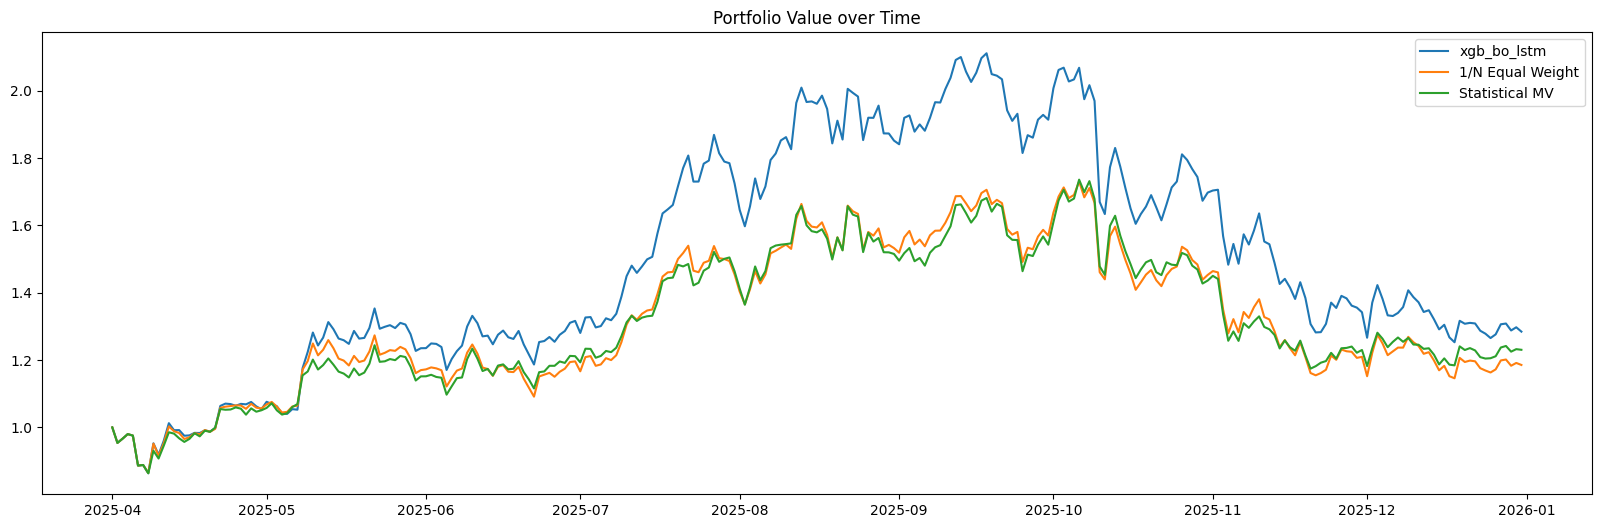

In [5]:

import matplotlib.pyplot as plt

plt.figure(figsize=(20, 6))

#plot best performing
best_csv_path = os.path.join('15 CMVO results', 'xgb_bo_lstm.csv')
best_df = pd.read_csv(best_csv_path)
# Plotting the 'portfolio_value' column from the CSV

n_csv_path = os.path.join('15 CMVO results', 'benchmark_1n.csv')
mv_csv_path = os.path.join('15 CMVO results', 'benchmark_mv.csv')

n_df = pd.read_csv(n_csv_path)
mv_df = pd.read_csv(mv_csv_path)

#add dates to data
for df in [best_df, mv_df, n_df]:
  dates = pd.date_range(end='2025-12-31', periods=275, freq='D') #test data is last 275 days with end date 31st dec 2025
  df.index = dates
  df.index.name = 'Date'


print(best_df.head())

#plot
plt.plot(best_df.index, best_df['portfolio_values'],label='xgb_bo_lstm')
plt.plot(n_df.index,n_df['portfolio_values'], label='1/N Equal Weight')
plt.plot(mv_df.index,mv_df['portfolio_values'], label='Statistical MV')

plt.title("Portfolio Value over Time")
plt.legend()
plt.show()


             ADAUSDT   BCHUSDT   BNBUSDT   BTCUSDT   ETHUSDT   SOLUSDT  \
Date                                                                     
2025-11-27 -0.088886 -0.054930 -0.382892 -0.138552 -0.104498 -0.057154   
2025-12-05 -0.130682 -0.048431 -0.310121 -0.061343 -0.031401 -0.009552   
2025-12-13 -0.014514 -0.040253 -0.276105  0.034659  0.005843 -0.055837   
2025-12-21  0.089385 -0.070474 -0.175257 -0.000667 -0.063531  0.071937   
2025-12-29 -0.083720 -0.098143 -0.234151 -0.009852  0.074612  0.027962   

             TRXUSDT   XRPUSDT  avg returns  
Date                                         
2025-11-27 -0.293664 -0.044595    -0.145646  
2025-12-05 -0.269800  0.034492    -0.103355  
2025-12-13 -0.279894  0.048180    -0.072240  
2025-12-21 -0.234331  0.150061    -0.029110  
2025-12-29 -0.252011  0.119611    -0.056962  


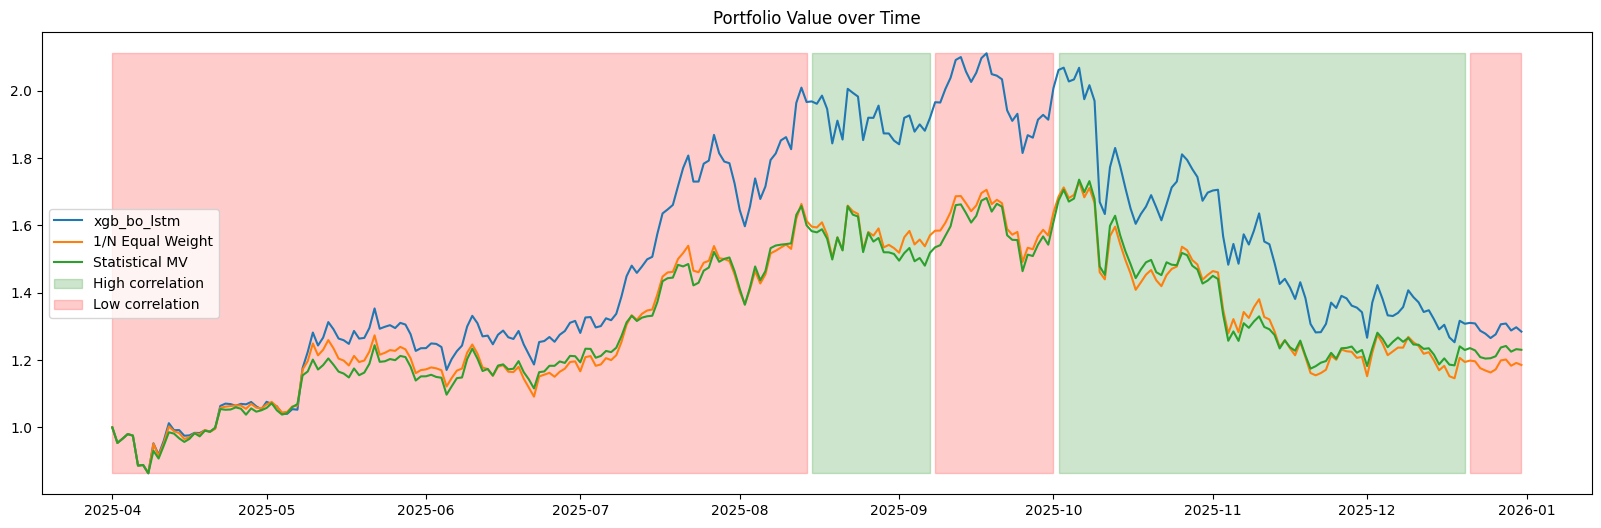

In [6]:
#load predicted correlations


returnpreds = pd.read_csv("15 CMVO results/bestmodelpredictions/xgb_bo_returns.csv")
correlation = pd.read_csv("15 CMVO results/bestmodelpredictions/lstm_correlations.csv")

returnpreds['avg returns'] = returnpreds.mean(axis=1)
dates = pd.date_range(start='2025-04-01', end='2025-12-31', freq='8D') #test data is last 275 days with end date 31st dec 2025
returnpreds.index = dates
returnpreds.index.name = 'Date'
print(returnpreds.tail())

correlation.index= dates
returnpreds.index.name = 'Date'

full_dates = pd.date_range(start='2025-04-01', end='2025-12-31', freq='D')
returnpreds = returnpreds.reindex(full_dates).ffill()
correlation = correlation.reindex(full_dates).ffill()

# 2. Reindex and fill values forward
# This creates rows for the missing days and copies the values from the last available 8-day prediction
returnpreds_daily = returnpreds.reindex(full_dates).ffill()


fig, ax = plt.subplots(figsize=(20, 6))

#plot
plt.plot(best_df.index, best_df['portfolio_values'],label='xgb_bo_lstm')
plt.plot(n_df.index,n_df['portfolio_values'], label='1/N Equal Weight')
plt.plot(mv_df.index,mv_df['portfolio_values'], label='Statistical MV')

# Highlight High Return Areas (Logic: Prediction > 0.02)
# ax.fill_between(dates, best_df['portfolio_values'].min(), best_df['portfolio_values'].max(),
#                 where=(returnpreds['avg returns']>returnpreds['avg returns'].mean()),
#                 color='green', alpha=0.2, label='High Return Regime')

# # Highlight Low/Negative Return Areas (Logic: Prediction < 0.005)
# ax.fill_between(dates, best_df['portfolio_values'].min(), best_df['portfolio_values'].max(),
#                 where=(returnpreds['avg returns']< returnpreds['avg returns'].mean()),
#                 color='red', alpha=0.2, label='Defensive Regime')


ax.fill_between(full_dates, best_df['portfolio_values'].min(), best_df['portfolio_values'].max(),
                where=(correlation['0']> correlation['0'].mean()),
                color='green', alpha=0.2, label='High correlation')

# Highlight Low/Negative Return Areas (Logic: Prediction < 0.005)
ax.fill_between(full_dates, best_df['portfolio_values'].min(), best_df['portfolio_values'].max(),
                where=(correlation['0']< correlation['0'].mean()),
                color='red', alpha=0.2, label='Low correlation')

ax.set_title('Portfolio Value with Conditional Return Highlights')
ax.legend()
plt.title("Portfolio Value over Time")
plt.legend()
plt.show()




             ADAUSDT   BCHUSDT   BNBUSDT   BTCUSDT   ETHUSDT   SOLUSDT  \
Date                                                                     
2025-11-27 -0.088886 -0.054930 -0.382892 -0.138552 -0.104498 -0.057154   
2025-12-05 -0.130682 -0.048431 -0.310121 -0.061343 -0.031401 -0.009552   
2025-12-13 -0.014514 -0.040253 -0.276105  0.034659  0.005843 -0.055837   
2025-12-21  0.089385 -0.070474 -0.175257 -0.000667 -0.063531  0.071937   
2025-12-29 -0.083720 -0.098143 -0.234151 -0.009852  0.074612  0.027962   

             TRXUSDT   XRPUSDT  avg returns  
Date                                         
2025-11-27 -0.293664 -0.044595    -0.145646  
2025-12-05 -0.269800  0.034492    -0.103355  
2025-12-13 -0.279894  0.048180    -0.072240  
2025-12-21 -0.234331  0.150061    -0.029110  
2025-12-29 -0.252011  0.119611    -0.056962  


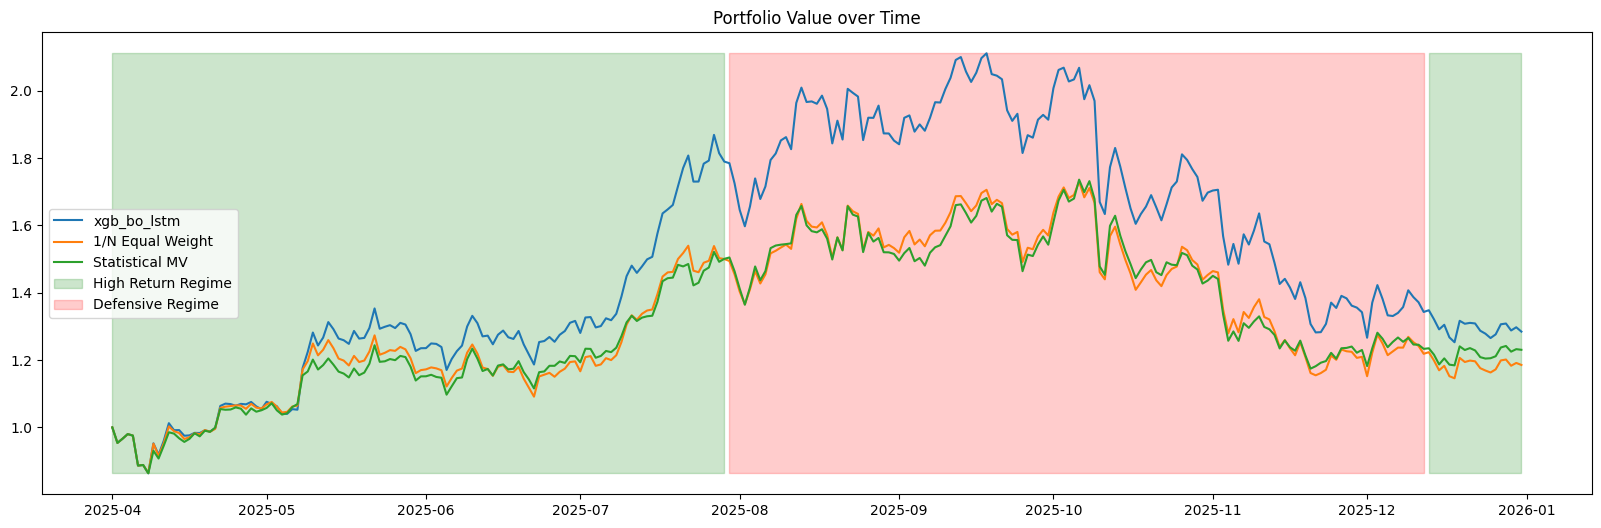

In [7]:
#load predicted returns

returnpreds = pd.read_csv("15 CMVO results/bestmodelpredictions/xgb_bo_returns.csv")
correlation = pd.read_csv("15 CMVO results/bestmodelpredictions/lstm_correlations.csv")

returnpreds['avg returns'] = returnpreds.mean(axis=1)
dates = pd.date_range(start='2025-04-01', end='2025-12-31', freq='8D') #test data is last 275 days with end date 31st dec 2025
returnpreds.index = dates
returnpreds.index.name = 'Date'
print(returnpreds.tail())

correlation.index= dates
returnpreds.index.name = 'Date'

full_dates = pd.date_range(start='2025-04-01', end='2025-12-31', freq='D')
returnpreds = returnpreds.reindex(full_dates).ffill()
correlation = correlation.reindex(full_dates).ffill()

# 2. Reindex and fill values forward
# This creates rows for the missing days and copies the values from the last available 8-day prediction
returnpreds_daily = returnpreds.reindex(full_dates).ffill()


fig, ax = plt.subplots(figsize=(20, 6))

#plot
plt.plot(best_df.index, best_df['portfolio_values'],label='xgb_bo_lstm')
plt.plot(n_df.index,n_df['portfolio_values'], label='1/N Equal Weight')
plt.plot(mv_df.index,mv_df['portfolio_values'], label='Statistical MV')

#Highlight High Return Areas (Logic: Prediction > 0.02)
ax.fill_between(full_dates, best_df['portfolio_values'].min(), best_df['portfolio_values'].max(),
                where=(returnpreds['avg returns']>returnpreds['avg returns'].mean()),
                color='green', alpha=0.2, label='High Return Regime')

# Highlight Low/Negative Return Areas (Logic: Prediction < 0.005)
ax.fill_between(full_dates, best_df['portfolio_values'].min(), best_df['portfolio_values'].max(),
                where=(returnpreds['avg returns']< returnpreds['avg returns'].mean()),
                color='red', alpha=0.2, label='Defensive Regime')


ax.set_title('Portfolio Value with Conditional Return Highlights')
ax.legend()
plt.title("Portfolio Value over Time")
plt.legend()
plt.show()




**Plot how portfolio weights change over test period for best performing portfolio**

            portfolio_values  pct_change   ADAUSDT   BCHUSDT   BNBUSDT  \
Date                                                                     
2025-04-01          1.000000    0.000000  0.125000  0.125000  0.125000   
2025-04-02          0.953985   -0.046015  0.123868  0.124608  0.126645   
2025-04-03          0.966531    0.013151  0.124323  0.126474  0.125422   
2025-04-04          0.980115    0.014055  0.124390  0.124763  0.124735   
2025-04-05          0.975603   -0.004604  0.123906  0.126462  0.124352   

             BTCUSDT   ETHUSDT   SOLUSDT   TRXUSDT   XRPUSDT  
Date                                                          
2025-04-01  0.125000  0.125000  0.125000  0.125000  0.125000  
2025-04-02  0.126964  0.123480  0.121461  0.128991  0.123984  
2025-04-03  0.126374  0.123371  0.119629  0.129546  0.124860  
2025-04-04  0.125636  0.121637  0.123630  0.128180  0.127029  
2025-04-05  0.125688  0.121469  0.121703  0.127964  0.128455  


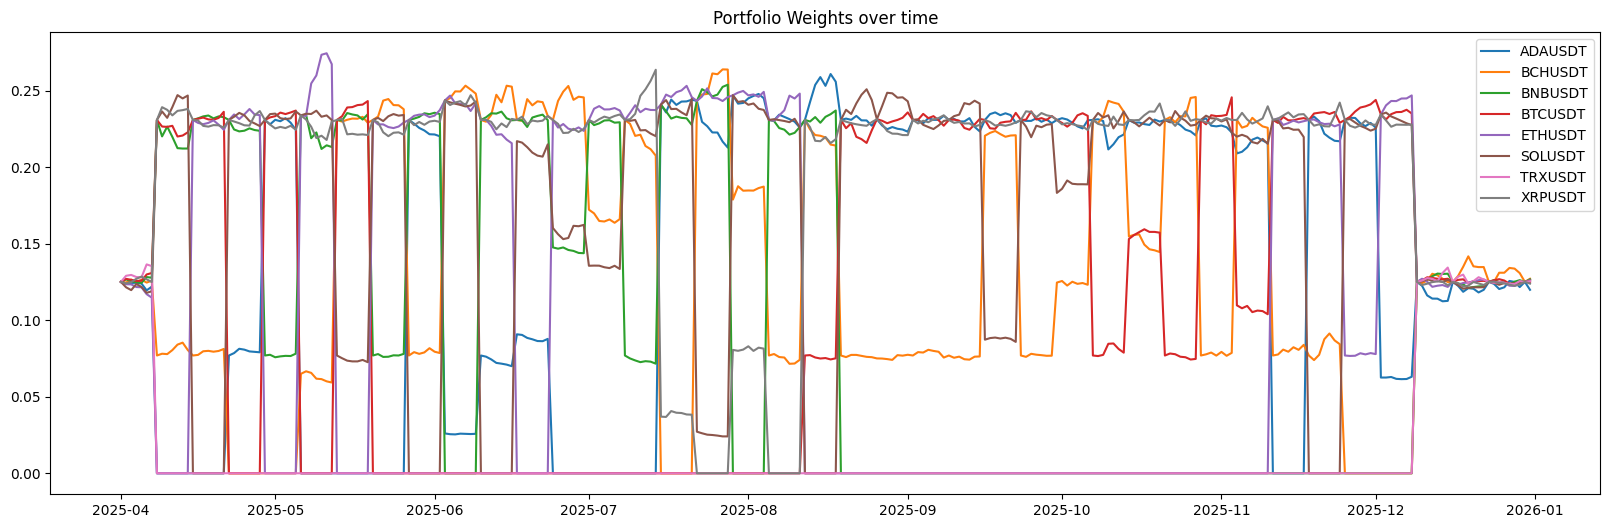

In [8]:
#plot how weights change overtime


print(best_df.head())

fig, ax = plt.subplots(figsize=(20, 6))
plt.plot(best_df.index, best_df['ADAUSDT'], label="ADAUSDT")
plt.plot(best_df.index, best_df['BCHUSDT'], label="BCHUSDT")
plt.plot(best_df.index, best_df['BNBUSDT'], label="BNBUSDT")
plt.plot(best_df.index, best_df['BTCUSDT'], label="BTCUSDT")
plt.plot(best_df.index, best_df['ETHUSDT'], label="ETHUSDT")
plt.plot(best_df.index, best_df['SOLUSDT'], label="SOLUSDT")
plt.plot(best_df.index, best_df['TRXUSDT'], label="TRXUSDT")
plt.plot(best_df.index, best_df['XRPUSDT'], label="XRPUSDT")

plt.title("Portfolio Weights over time")
plt.legend()
plt.show()


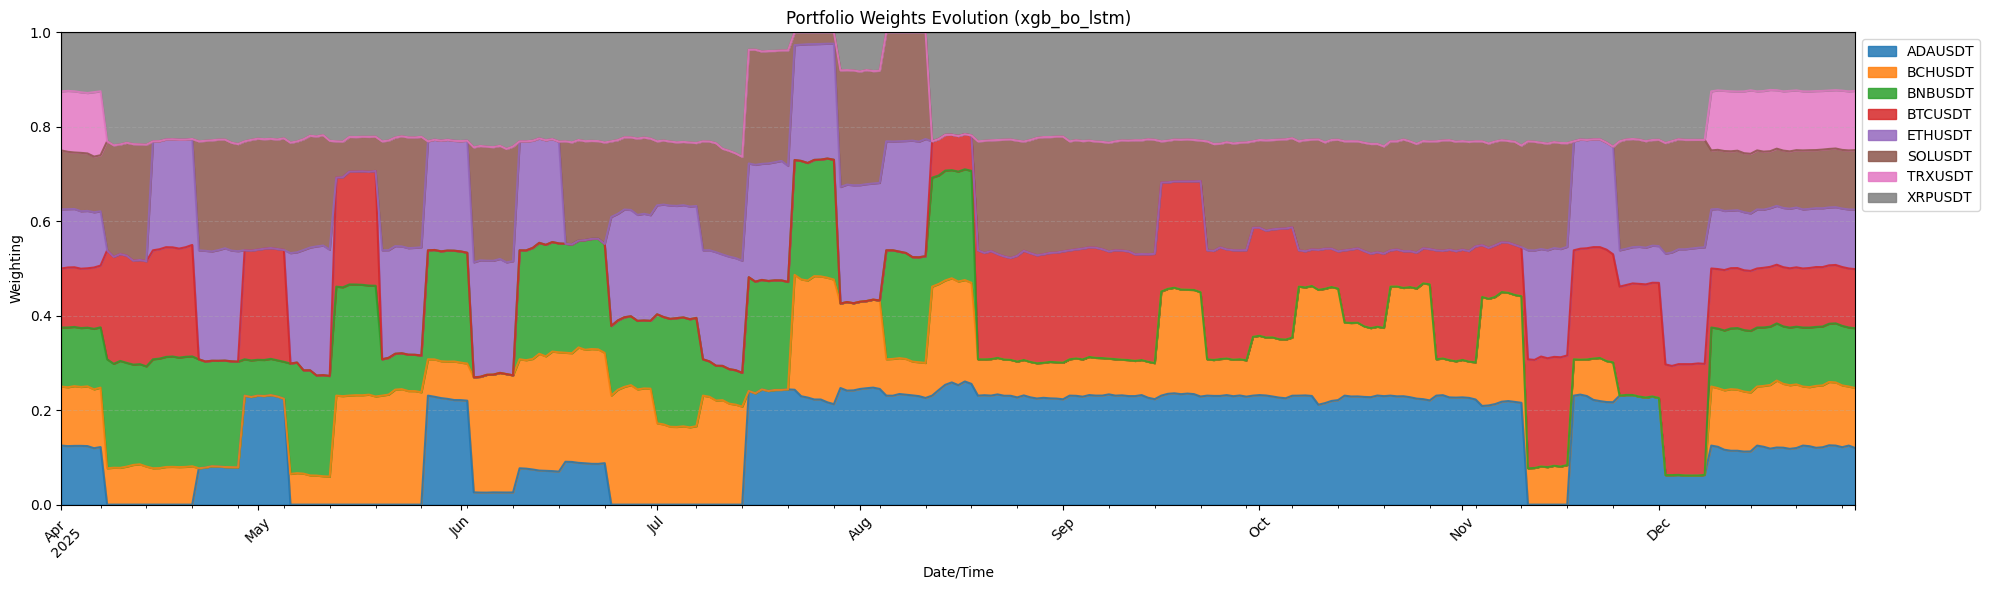

In [9]:
import matplotlib.pyplot as plt

# 1. Exclude the first 2 columns using iloc
# .iloc[:, 2:] means "all rows, and columns from index 2 to the end"
plot_df = best_df.iloc[:, 2:]

# 2. Plotting as a Stacked Area Chart
# stacked=True is the default for .area(), but we keep it for clarity
ax = plot_df.plot.area(stacked=True, figsize=(20, 6), alpha=0.85)

# 3. Formatting
plt.title("Portfolio Weights Evolution (xgb_bo_lstm)")
plt.ylabel("Weighting")
plt.xlabel("Date/Time")

# Adjusting the Y-axis to ensure it shows the 0-1 scale clearly
plt.ylim(0, 1.0)

# Legend placement
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0))

# Clean up x-axis labels if they are overlapping
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

os.makedirs('16 Analysis results', exist_ok=True)
plt.savefig('16 Analysis results/portfolio_weights_area_chart.png')
plt.show()

**Plot how portfolio weights change over test period for mean variance benchmark**

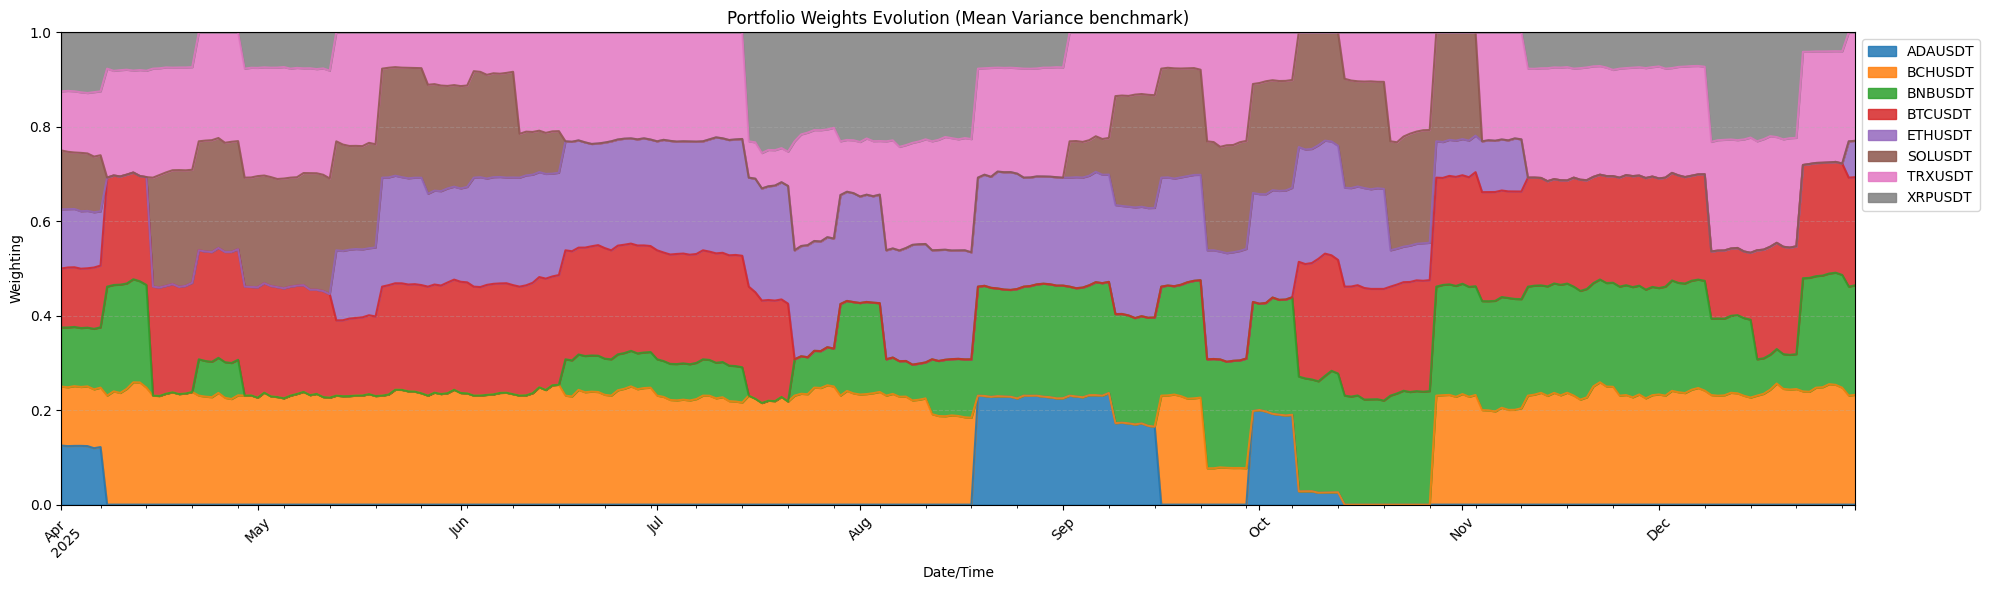

In [10]:
#mean variance benchmark portfolio weights over time

import matplotlib.pyplot as plt

# 1. Exclude the first 2 columns using iloc
# .iloc[:, 2:] means "all rows, and columns from index 2 to the end"
plot_df = mv_df.iloc[:, 2:]

# 2. Plotting as a Stacked Area Chart
# stacked=True is the default for .area(), but we keep it for clarity
ax = plot_df.plot.area(stacked=True, figsize=(20, 6), alpha=0.85)

# 3. Formatting
plt.title("Portfolio Weights Evolution (Mean Variance benchmark)")
plt.ylabel("Weighting")
plt.xlabel("Date/Time")

# Adjusting the Y-axis to ensure it shows the 0-1 scale clearly
plt.ylim(0, 1.0)

# Legend placement
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0))

# Clean up x-axis labels if they are overlapping
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

os.makedirs('16 Analysis results', exist_ok=True)
plt.savefig('16 Analysis results/portfolio_weights_area_chart.png')
plt.show()

**Plot predicted returns taken as input for CMVO for best performing portfolio**

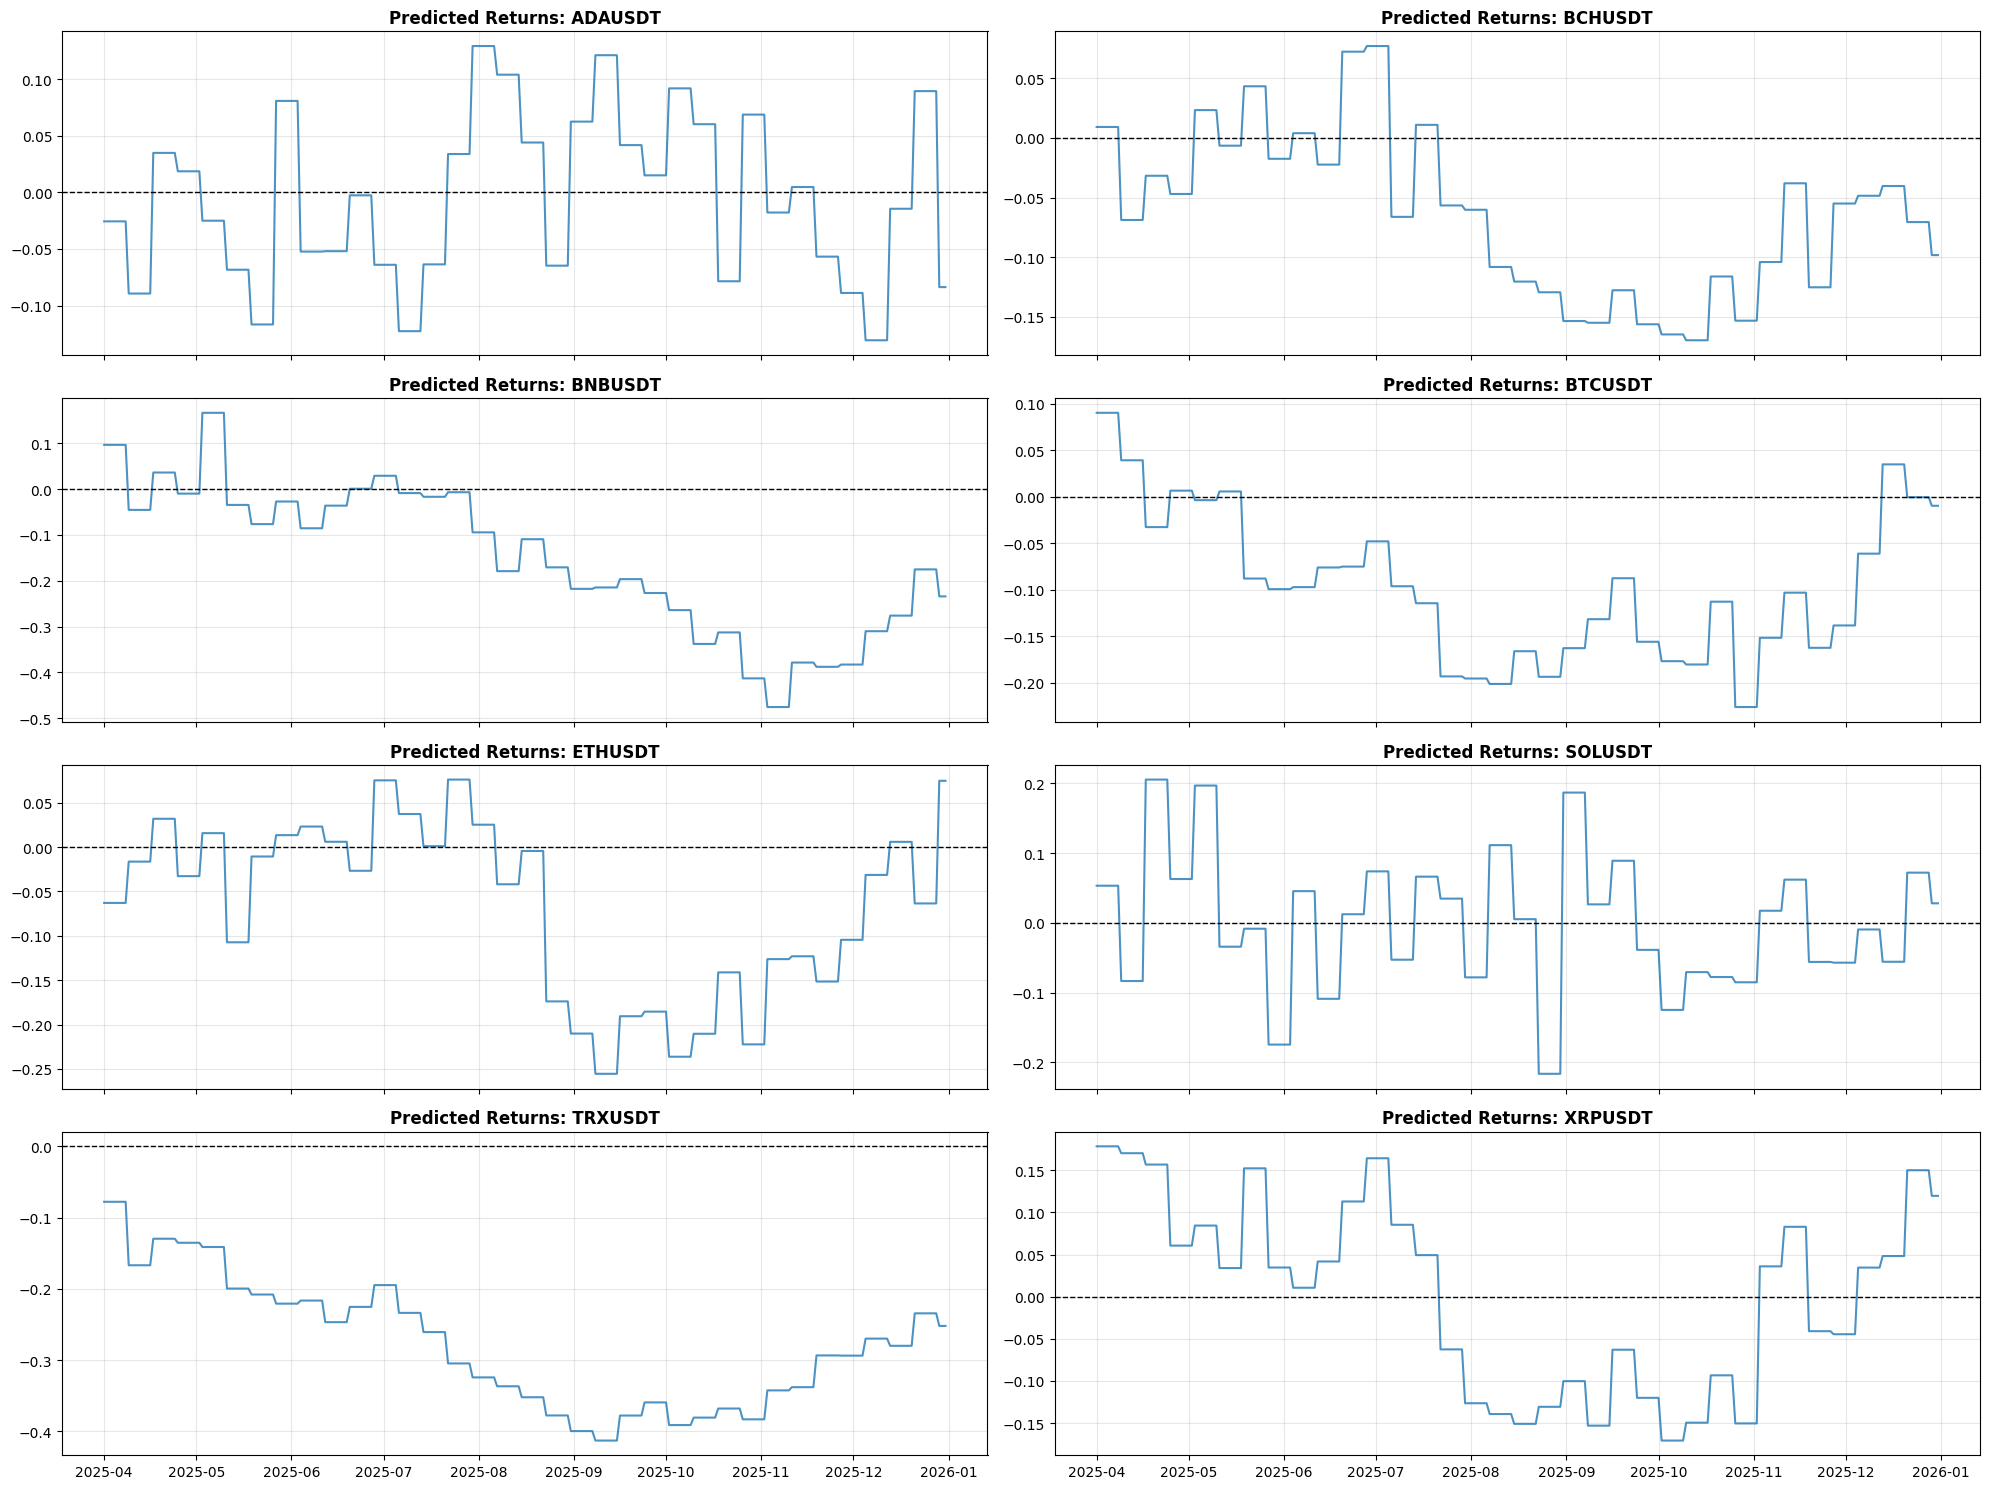

In [11]:
import matplotlib.pyplot as plt

#PLOT XGB_BO RETURNS OVER TEST PERIOD FOR EACH COIN

# 1. Ensure columns are clean
returnpreds.columns = [c for c in returnpreds.columns if not c.endswith(('.keras', '.npy', '.csv'))]

# 2. Filter out 'avg returns' if it exists
plot_cols = [c for c in returnpreds.columns if c != 'avg returns']
n_coins = len(plot_cols)

# 3. Create a grid of subplots (4 rows, 2 columns)
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(20, 15), sharex=True)
axes = axes.flatten()  # Flatten to easily loop through them

for i, col in enumerate(plot_cols):
    ax = axes[i]
    ax.plot(returnpreds.index, returnpreds[col], color='tab:blue', alpha=0.8)

    # Labeling each subplot
    ax.set_title(f'Predicted Returns: {col}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='black', lw=1, ls='--') # Reference line at 0

# Adjust layout so titles don't overlap
plt.tight_layout()

# Define your save path
os.makedirs("16 Analysis results", exist_ok=True)
save_path = "16 Analysis results/xgb_bo_returns.png"

# Save the figure
# 'bbox_inches=tight' ensures the legend and labels aren't cut off
plt.savefig(save_path, dpi=300, bbox_inches='tight', transparent=False)
plt.show()
